# Cloud-Native Analysis of FSM-PK Using Zenodo COG

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/waleedgeo/FSM-PK/blob/main/notebooks/01_zenodo_cog_analysis.ipynb)

This notebook demonstrates **cloud-native geospatial analysis** of the Pakistan Flood Susceptibility Map (FSM-PK) dataset using Cloud Optimized GeoTIFFs (COG) hosted on Zenodo.

## Objectives

1. Access FSM-PK data directly from Zenodo without downloading
2. Perform windowed reads for a specific region (Karachi)
3. Visualize flood susceptibility with discrete colormaps
4. Calculate area statistics by susceptibility class

## About the Dataset

- **Resolution**: 30 meters
- **Model**: LightGBM (0.85 accuracy)
- **Classes**: 1-5 (Very Low to Very High susceptibility)
- **Zenodo DOI**: [10.5281/zenodo.18513601](https://doi.org/10.5281/zenodo.18513601)

## Citation

```
Waleed, M., & Sajjad, M. (2025). High-resolution flood susceptibility mapping
and exposure assessment in Pakistan: An integrated artificial intelligence,
machine learning and geospatial framework. International Journal of Disaster
Risk Reduction, 121, 105442. https://doi.org/10.1016/j.ijdrr.2025.105442
```

---

## 1. Setup and Installation

Install required packages (only needed in Google Colab):

In [ ]:
# Uncomment and run if using Google Colab
# !pip install rioxarray rasterio matplotlib numpy pyproj -q

### Import Libraries

In [1]:
import rioxarray as rxr
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
from matplotlib.patches import Patch
import warnings

warnings.filterwarnings('ignore')

print('All packages imported successfully!')

All packages imported successfully!


---

## 2. Define Constants and Configuration

In [2]:
# Zenodo COG URL (LGBM model)
FSM_URL = 'https://zenodo.org/records/18513602/files/fsm_lgbm_pakistan.tif'

# Karachi bounding box in geographic coordinates [min_lon, min_lat, max_lon, max_lat]
KARACHI_BBOX_GEOGRAPHIC = [66.5, 24.7, 67.5, 25.7]

# Convert to EPSG:3395 (World Mercator) for projected CRS compatibility
from pyproj import Transformer
transformer = Transformer.from_crs("EPSG:4326", "EPSG:3395", always_xy=True)

# Transform corner points
min_x, min_y = transformer.transform(KARACHI_BBOX_GEOGRAPHIC[0], KARACHI_BBOX_GEOGRAPHIC[1])
max_x, max_y = transformer.transform(KARACHI_BBOX_GEOGRAPHIC[2], KARACHI_BBOX_GEOGRAPHIC[3])

# Karachi bounding box in EPSG:3395 [min_x, min_y, max_x, max_y]
KARACHI_BBOX = [min_x, min_y, max_x, max_y]

# Flood susceptibility classification
FSM_CLASSES = {1: 'Very Low', 2: 'Low', 3: 'Moderate', 4: 'High', 5: 'Very High'}

# Color palette (green to red)
FSM_COLORS = ['#2E7D32', '#7CB342', '#FDD835', '#FB8C00', '#C62828']

print(f'Data URL: {FSM_URL}')
print(f'Study Area: Karachi (Geographic): {KARACHI_BBOX_GEOGRAPHIC}')
print(f'Study Area: Karachi (EPSG:3395): [{min_x:.2f}, {min_y:.2f}, {max_x:.2f}, {max_y:.2f}]')
print(f'Classes: {list(FSM_CLASSES.values())}')

Data URL: https://zenodo.org/records/18513602/files/fsm_lgbm_pakistan.tif
Study Area: Karachi (Geographic): [66.5, 24.7, 67.5, 25.7]
Study Area: Karachi (EPSG:3395): [7402746.14, 2821092.22, 7514065.63, 2943447.84]
Classes: ['Very Low', 'Low', 'Moderate', 'High', 'Very High']


---

## 3. Cloud-Native Data Access

### Load Data with Windowed Read

We will use `rioxarray` to read **only the Karachi region** from the COG without downloading the entire national dataset.

In [3]:
print('Loading FSM data for Karachi...')
print('(This may take 10-30 seconds depending on your internet speed)\n')

# Open the COG with rioxarray
fsm_data = rxr.open_rasterio(FSM_URL, masked=True)

# Perform windowed read using bounding box
karachi_fsm = fsm_data.rio.clip_box(
    minx=KARACHI_BBOX[0], miny=KARACHI_BBOX[1],
    maxx=KARACHI_BBOX[2], maxy=KARACHI_BBOX[3]
)

print('Data loaded successfully!')
print(f'\nData Info:')
print(f'  Shape: {karachi_fsm.shape}')
print(f'  CRS: {karachi_fsm.rio.crs}')
print(f'  Resolution: {karachi_fsm.rio.resolution()}')
print(f'  Value range: {karachi_fsm.min().values} - {karachi_fsm.max().values}')

Loading FSM data for Karachi...
(This may take 10-30 seconds depending on your internet speed)

Data loaded successfully!

Data Info:
  Shape: (1, 4079, 3711)
  CRS: EPSG:3395
  Resolution: (30.0, -30.0)
  Value range: 1.0 - 5.0


---

## 4. Visualization

### Create Discrete Colormap for 5 Classes

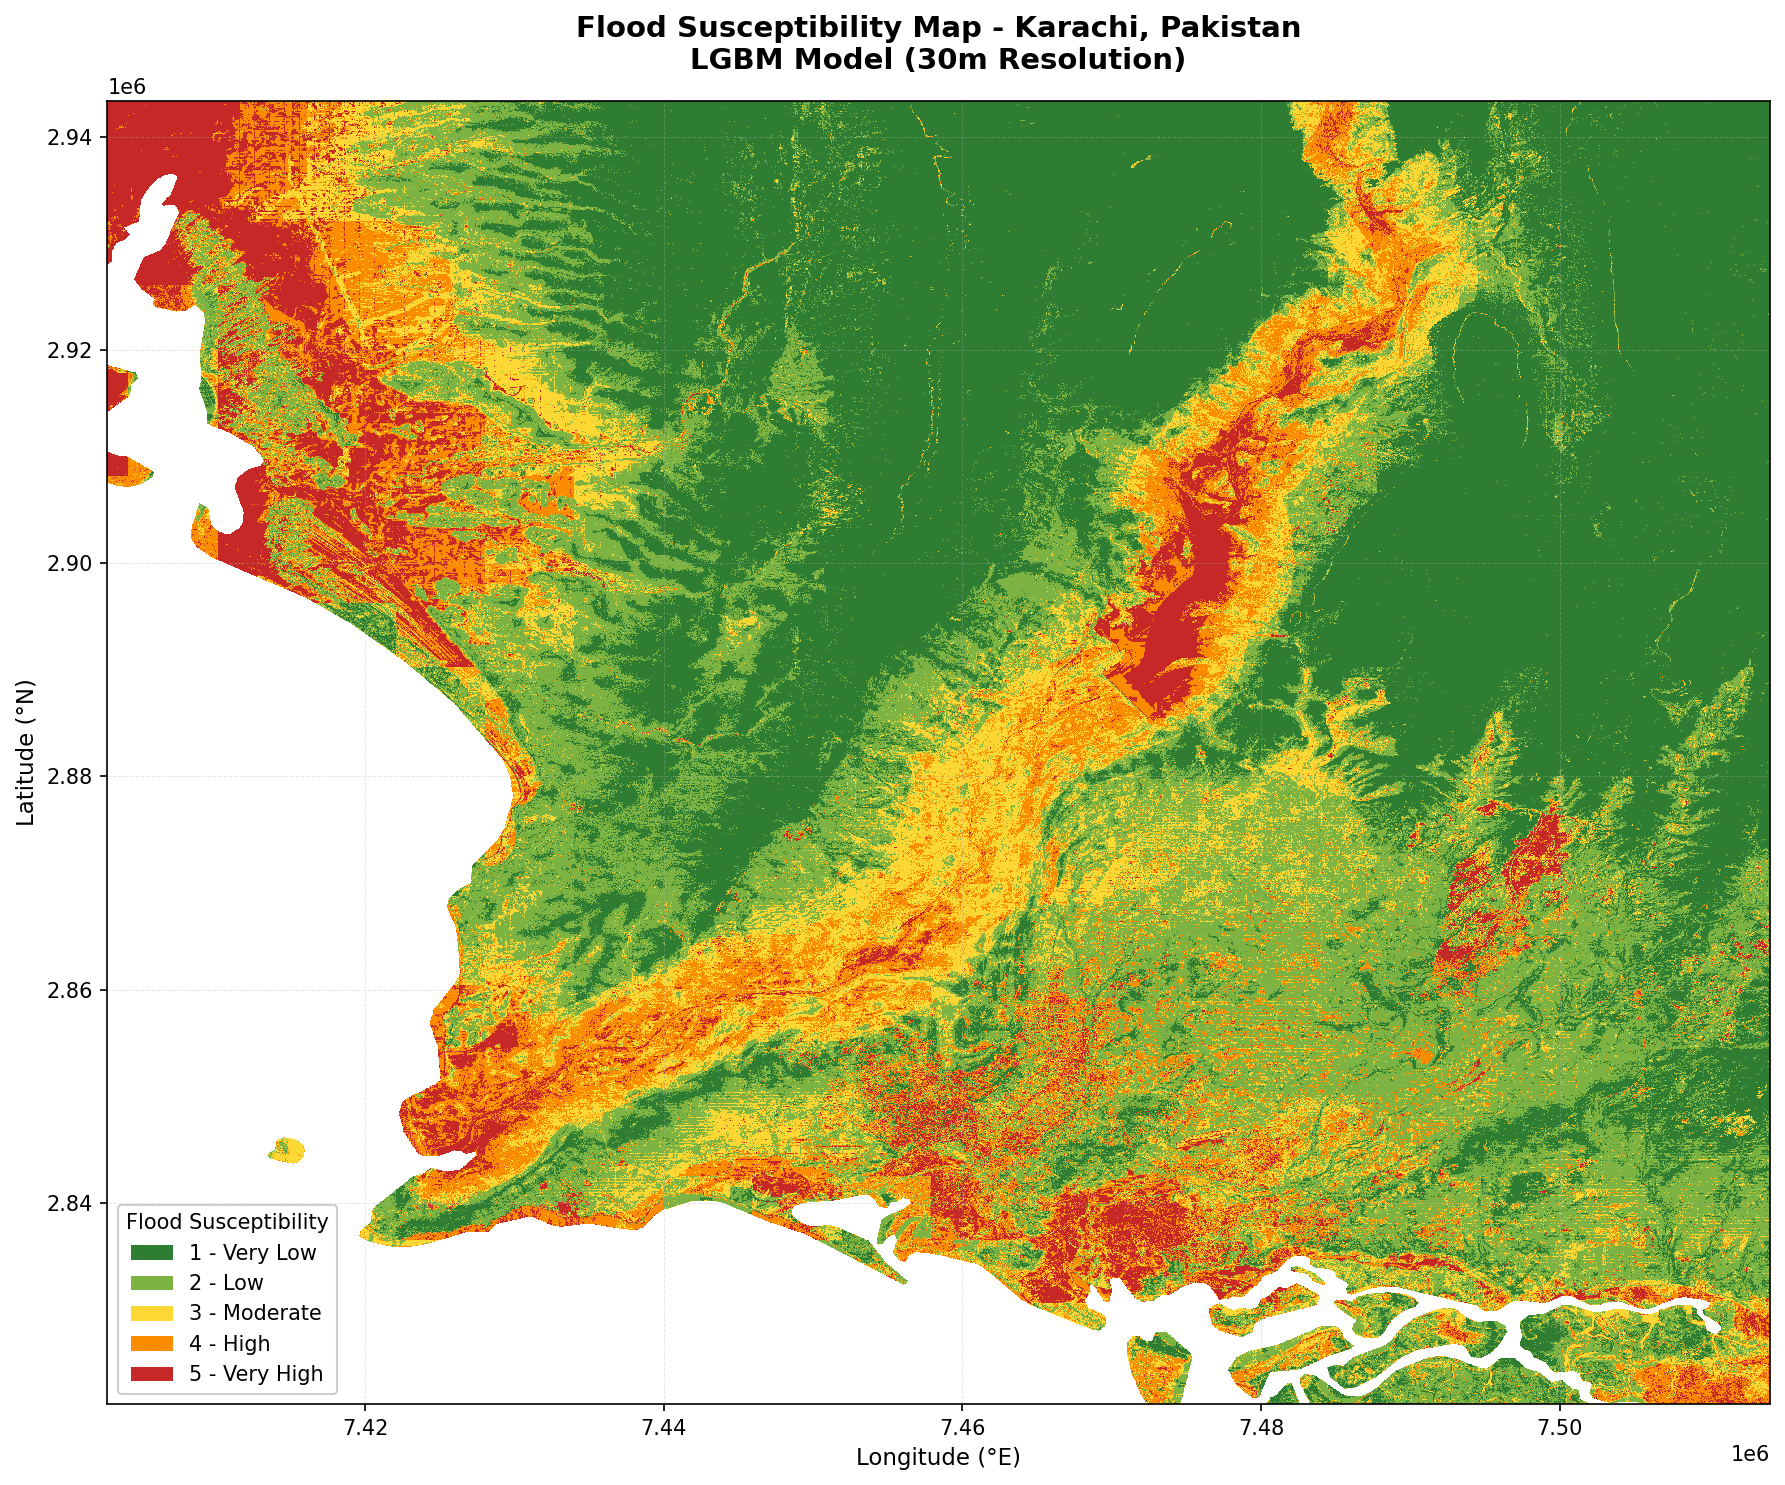


Visualization complete!


In [4]:
# Create discrete colormap
cmap = mcolors.ListedColormap(FSM_COLORS)
bounds = [0.5, 1.5, 2.5, 3.5, 4.5, 5.5]
norm = mcolors.BoundaryNorm(bounds, cmap.N)

# Create figure
fig, ax = plt.subplots(figsize=(12, 10), dpi=150)

# Plot the FSM data
im = karachi_fsm.squeeze().plot(ax=ax, cmap=cmap, norm=norm, add_colorbar=False)

# Add title and labels
ax.set_title('Flood Susceptibility Map - Karachi, Pakistan\nLGBM Model (30m Resolution)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Longitude (°E)', fontsize=11)
ax.set_ylabel('Latitude (°N)', fontsize=11)

# Create custom legend
legend_elements = [Patch(facecolor=FSM_COLORS[i], label=f'{i+1} - {FSM_CLASSES[i+1]}') for i in range(5)]
ax.legend(handles=legend_elements, loc='lower left', title='Flood Susceptibility', fontsize=10, framealpha=0.95)

# Add grid
ax.grid(True, linestyle='--', alpha=0.3, linewidth=0.5)

plt.tight_layout()
plt.show()

print('\nVisualization complete!')

---

## 5. Statistical Analysis

### Calculate Area by Susceptibility Class

In [5]:
# Get pixel resolution
res_x, res_y = karachi_fsm.rio.resolution()
pixel_area_km2 = abs(res_x * 101 * res_y * 111)  # Approximate at 25°N

# Extract data array
data_array = karachi_fsm.squeeze().values

# Calculate statistics
print('\n' + '='*60)
print('FLOOD SUSCEPTIBILITY STATISTICS - KARACHI')
print('='*60)

total_pixels = 0
area_by_class = {}

for class_value, class_name in FSM_CLASSES.items():
    pixel_count = np.sum(data_array == class_value)
    area_km2 = pixel_count * pixel_area_km2
    area_by_class[class_value] = {'pixels': pixel_count, 'area_km2': area_km2}
    total_pixels += pixel_count

print(f'\nTotal analyzed area: {total_pixels * pixel_area_km2:.2f} km²\n')

for class_value, class_name in FSM_CLASSES.items():
    pixels = area_by_class[class_value]['pixels']
    area = area_by_class[class_value]['area_km2']
    percentage = (pixels / total_pixels * 100) if total_pixels > 0 else 0
    print(f'Class {class_value} ({class_name:12s}): {area:8.2f} km² ({percentage:5.2f}%)')

print('\n' + '='*60)


FLOOD SUSCEPTIBILITY STATISTICS - KARACHI

Total analyzed area: 121940578359000.00 km²

Class 1 (Very Low    ): 49814734301100.00 km² (40.85%)
Class 2 (Low         ): 33414600751200.00 km² (27.40%)
Class 3 (Moderate    ): 15424218242100.00 km² (12.65%)
Class 4 (High        ): 14179175031600.00 km² (11.63%)
Class 5 (Very High   ): 9107850033000.00 km² ( 7.47%)



### Visualize Area Distribution

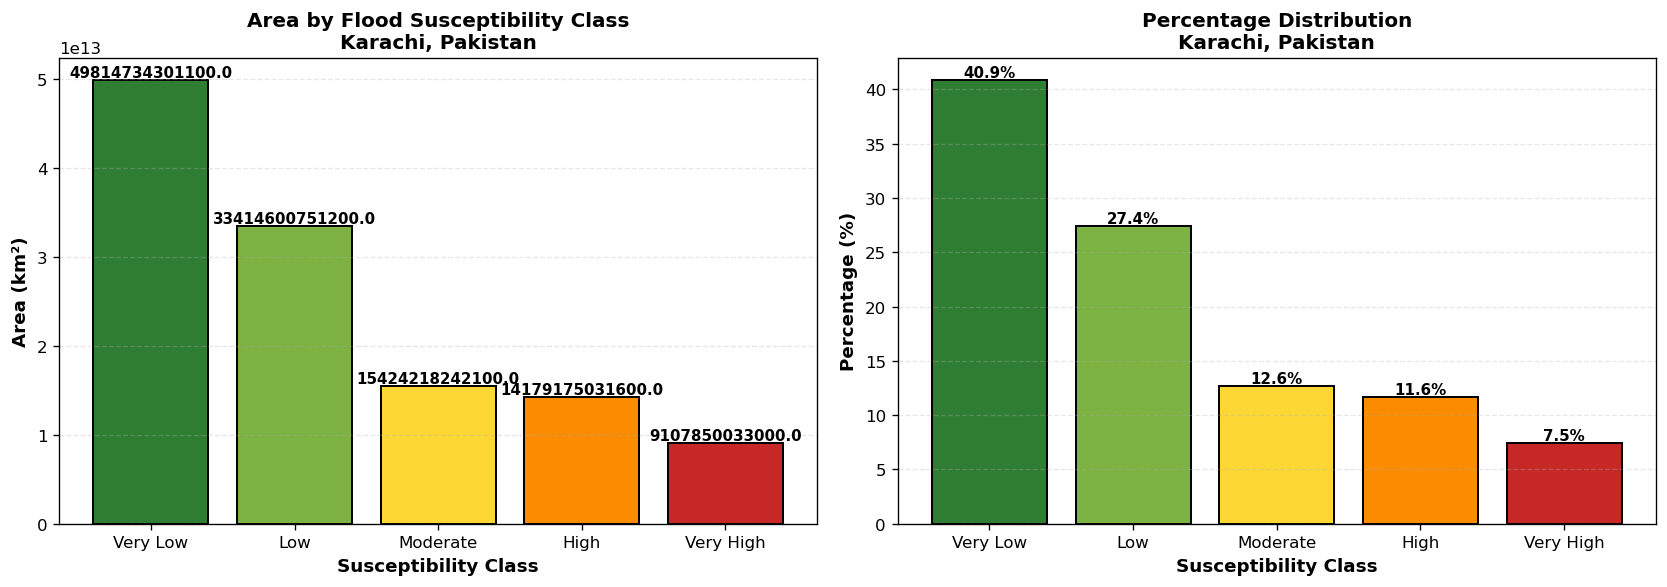


Statistical analysis complete!


In [6]:
# Prepare data
classes = list(FSM_CLASSES.values())
areas = [area_by_class[i+1]['area_km2'] for i in range(5)]
percentages = [(area_by_class[i+1]['pixels'] / total_pixels * 100) for i in range(5)]

# Create bar charts
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), dpi=120)

# Area chart
bars1 = ax1.bar(classes, areas, color=FSM_COLORS, edgecolor='black', linewidth=1.2)
ax1.set_xlabel('Susceptibility Class', fontsize=11, fontweight='bold')
ax1.set_ylabel('Area (km²)', fontsize=11, fontweight='bold')
ax1.set_title('Area by Flood Susceptibility Class\nKarachi, Pakistan', fontsize=12, fontweight='bold')
ax1.grid(axis='y', alpha=0.3, linestyle='--')

for bar, area in zip(bars1, areas):
    ax1.text(bar.get_x() + bar.get_width()/2., bar.get_height(), f'{area:.1f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# Percentage chart
bars2 = ax2.bar(classes, percentages, color=FSM_COLORS, edgecolor='black', linewidth=1.2)
ax2.set_xlabel('Susceptibility Class', fontsize=11, fontweight='bold')
ax2.set_ylabel('Percentage (%)', fontsize=11, fontweight='bold')
ax2.set_title('Percentage Distribution\nKarachi, Pakistan', fontsize=12, fontweight='bold')
ax2.grid(axis='y', alpha=0.3, linestyle='--')

for bar, pct in zip(bars2, percentages):
    ax2.text(bar.get_x() + bar.get_width()/2., bar.get_height(), f'{pct:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

print('\nStatistical analysis complete!')

---

## 6. Key Findings

### Interpretation

Based on the analysis above:

1. **Spatial Distribution**: Flood susceptibility in Karachi varies significantly across the city
2. **High-Risk Areas**: Areas classified as High or Very High require immediate attention
3. **Urban Planning**: This data can inform urban development and disaster preparedness

### Next Steps

- Compare LGBM vs XGBoost model outputs
- Overlay with population density data
- Export results for GIS analysis

---

## Additional Resources

- **Paper**: [https://doi.org/10.1016/j.ijdrr.2025.105442](https://doi.org/10.1016/j.ijdrr.2025.105442)
- **Data**: [https://doi.org/10.5281/zenodo.18513601](https://doi.org/10.5281/zenodo.18513601)
- **Interactive App**: [https://waleedgeo-ee.projects.earthengine.app/view/fsm-pk](https://waleedgeo-ee.projects.earthengine.app/view/fsm-pk)
- **GitHub**: [https://github.com/waleedgeo/FSM-PK](https://github.com/waleedgeo/FSM-PK)

---

## Contact

**Mirza Waleed**
- Email: waleedgeo@outlook.com
- Website: [waleedgeo.com](https://waleedgeo.com)
- LinkedIn: [linkedin.com/in/waleedgeo](https://www.linkedin.com/in/waleedgeo)